# JUMP-SCOPE → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes where the source recorded stage coordinates, and the well- and cell-level measurements become the `wells` and `cells` Tables.

The profile sits under `backend/` rather than `profiles/`, and there are no stage coordinates.

One well of `cpg0002-jump-scope`, fetched with the script beside this notebook:

```bash
python fetch.py cpg0002-jump-scope/source_4 2020_10_27_Scope1_YokogawaJapan 20201020T134356 A01
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0002-jump-scope/source_4").expanduser()
BATCH = "2020_10_27_Scope1_YokogawaJapan"
PLATE = "20201020T134356"
CHANNEL = "DNA"

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = cpio.read_plate(
    DATA_ROOT, BATCH, PLATE, profile=DATA_ROOT / "workspace/backend" / BATCH / PLATE / f"{PLATE}.csv.gz"
)
sdata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── '20201020T134356_A01_s1_image': DataTree[cyx] (5, 2000, 2000), (5, 1000, 1000), (5, 500, 500)
│     └── '20201020T134356_A01_s2_image': DataTree[cyx] (5, 2000, 2000), (5, 1000, 1000), (5, 500, 500)
├── Labels
│     ├── '20201020T134356_A01_s1_cells': DataArray[yx] (2000, 2000)
│     ├── '20201020T134356_A01_s1_cytoplasm': DataArray[yx] (2000, 2000)
│     ├── '20201020T134356_A01_s1_nuclei': DataArray[yx] (2000, 2000)
│     ├── '20201020T134356_A01_s2_cells': DataArray[yx] (2000, 2000)
│     ├── '20201020T134356_A01_s2_cytoplasm': DataArray[yx] (2000, 2000)
│     └── '20201020T134356_A01_s2_nuclei': DataArray[yx] (2000, 2000)
└── Tables
      ├── 'cells': AnnData (212, 1179)
      └── 'wells': AnnData (384, 4593)
with coordinate systems:
    ▸ '20201020T134356_A01_s1', with elements:
        20201020T134356_A01_s1_image (Images), 20201020T134356_A01_s1_cells (Labels), 20201020T134356_A01_s1_cytoplasm (Labels), 20201020T134356_A01_s1_nuclei (Labels

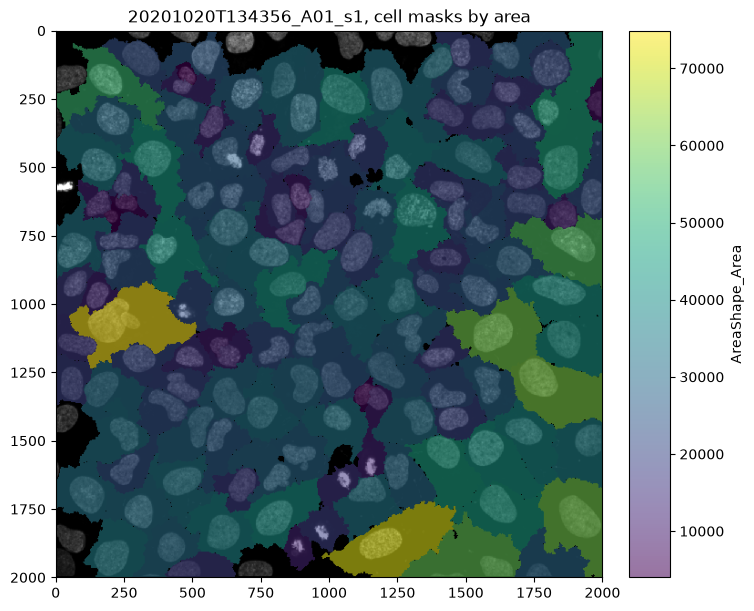

In [3]:
fov = next(name.removesuffix("_cells") for name in sdata.labels if name.endswith("_cells"))
values = sd.get_pyramid_levels(sdata[f"{fov}_image"], n=0).sel(c=CHANNEL).to_numpy()
(
    sdata.pl.render_images(
        f"{fov}_image", channel=CHANNEL, cmap="gray", norm=Normalize(*np.percentile(values, [50, 99.9])), colorbar=False
    )
    .pl.render_labels(f"{fov}_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=fov, figsize=(6.5, 6), title=f"{fov}, cell masks by area")
)